In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [75]:
data=pd.read_csv(r"C:\Users\komal\Downloads\image\housing.csv")

In [76]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [77]:
print(data.shape)

(20640, 10)


In [78]:
print("Missing Values:\n", data.isnull().sum())


Missing Values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [79]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
data[["total_bedrooms"]] = imputer.fit_transform(data[["total_bedrooms"]])


In [80]:
print("Missing Values:\n", data.isnull().sum())

Missing Values:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [81]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [82]:
print(data.columns)
print(data.dtypes)


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [83]:
y = data["median_house_value"]

# Features (drop target column)
X = data.drop("median_house_value", axis=1)


In [84]:
print(y)

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [89]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [100]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
,
    "Random Forest": RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

}


In [101]:
results = {}
for name, model in models.items():
    
    full_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    # Train
    full_pipeline.fit(X_train, y_train_log)
    
    # Predict (log scale)
    y_pred_log = full_pipeline.predict(X_test)
    
    # Convert back to original scale
    y_pred = np.expm1(y_pred_log)
    
    # Metrics (on original scale)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [96]:
print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OneHotEncoder())]),
                                 Index(['ocean_proximity'], dtype='object'))])


In [102]:
results_df = pd.DataFrame(results).T
print(results_df)


                            MSE           MAE          RMSE        R2
Linear Regression  7.927678e+09  52273.686535  89037.507031  0.395023
Decision Tree      3.370531e+09  37761.264372  58056.271361  0.742788
Random Forest      2.488364e+09  31162.793447  49883.505580  0.810108


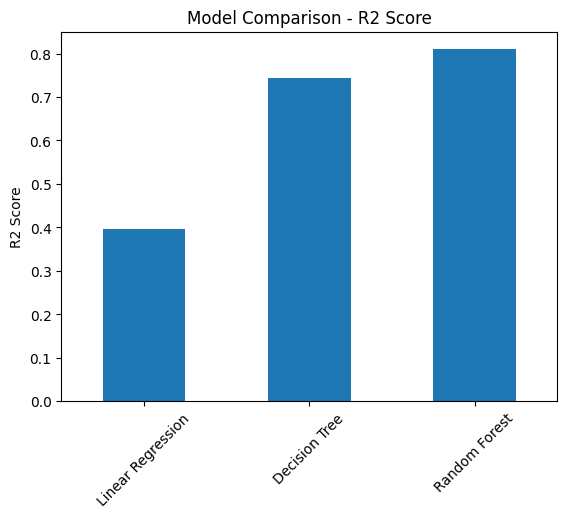

In [103]:
results_df["R2"].plot(kind="bar")
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

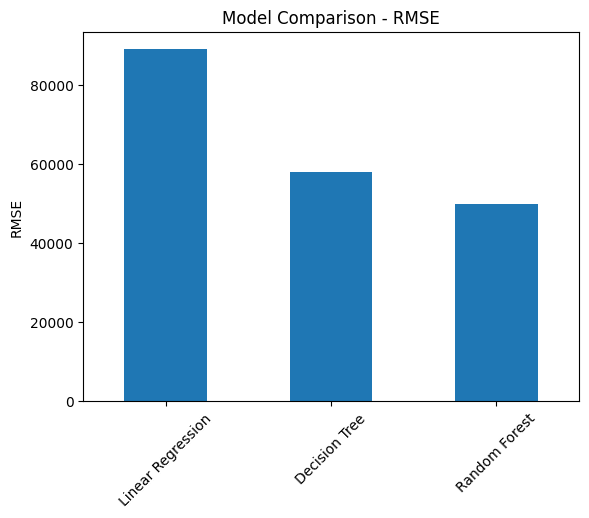

In [104]:
results_df["RMSE"].plot(kind="bar")
plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

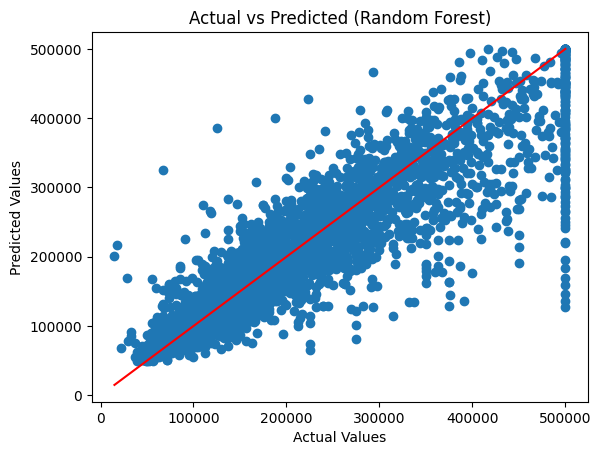

In [106]:
best_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
)
])

best_model.fit(X_train, y_train_log)
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()
